In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


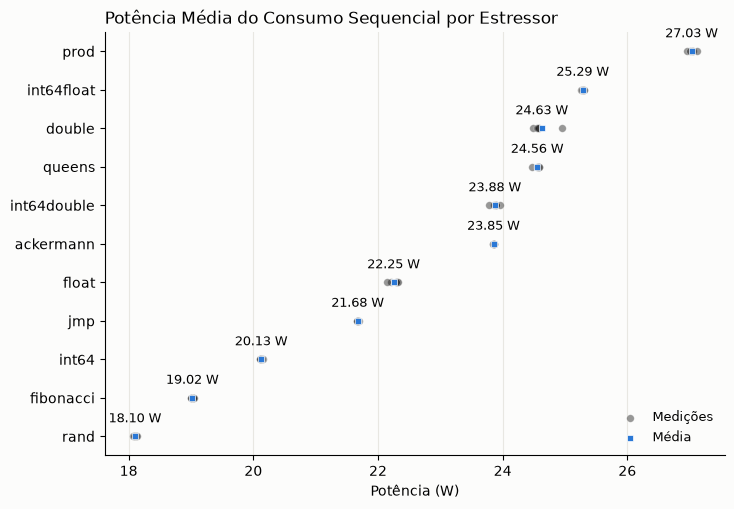

                                             Stress-ng      Média  Variância  \
0    stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.472399   0.008322   
2    stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.837423   0.016194   
4    stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.845729   0.006562   
6    stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.859919   0.002746   
8    stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.867004   0.005981   
10   stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.860008   0.003420   
12   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.582953   0.011762   
14   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.575475   0.009194   
16   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.578151   0.005752   
18   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.568667   0.010323   
20   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.555918   0.014174   
22   stress-ng---cpu-6---cpu-method-fibo

In [22]:


cons = pd.read_csv("log_medicao_sequencial.csv",
                   names=["Stress-ng", "Média", "Variância"])
#ons = pd.read_csv("log_medicao_paralela.csv", names=["Stress-ng", "Média", "Variância"])

'''cons = cons.rename(columns={
    "stress-ng---cpu-6---cpu-method-queens--t-30-20260924_121141.csv": "Stress-ng",
    "24.4723993227684": "Info",
    "0.008322237037118985": "Média"
    })
'''

#print(cons.columns)

#cons = cons[~cons.astype(str).apply(lambda linha : linha.str.contains("n"),any(), axis=1)]

filtrado = cons.copy()

filtrado = filtrado.dropna(subset=["Variância"])

metodos = filtrado['Stress-ng'].str.findall(r'-method-([^-]+)')
filtrado['método'] = metodos.str[0]
filtrado['método2'] = metodos.str[1]
filtrado['par'] = metodos.apply(lambda m: tuple(sorted(m)))

filtrado['cpu'] = filtrado["Stress-ng"].str.split('--').str[1]

filtrado['tempo'] = filtrado['Stress-ng'].str.extract(r't-([^-]+)')
#tempo = filtrado["Stress-ng"].str.split('--').str[3]
#filtrado['tempo'] = tempo.str.split('-').str[1]

filtrado['data'] = filtrado['Stress-ng'].str.extract(r't-30-([^-]+)')
#data = filtrado["Stress-ng"].str.split('-').str[14]
#filtrado["data"] = data.str.split('_').str[0]

grupo = filtrado.groupby("método")["Média"]
#variância = grupo.var()


# ===== INÍCIO: pontos individuais em preto + média em quadrado azul pequeno =====
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["savefig.facecolor"] = "#fcfcfb"
plt.rcParams["savefig.transparent"] = False

ordem = filtrado.groupby('método')['Média'].mean().sort_values().index

fig, ax = plt.subplots(figsize=(8, 5.5))
for i, metodo in enumerate(ordem):
    valores = filtrado.loc[filtrado['método'] == metodo, 'Média']
    ax.scatter(valores, [i] * len(valores), s=30, color="black", alpha=0.4,
               edgecolors="white", linewidths=0.5, zorder=2,
               label="Medições" if i == 0 else None)
    media = valores.mean()
    ax.scatter([media], [i], s=20, marker="s", color="#2a78d6", edgecolors="white",
            linewidths=0.5, zorder=3, label="Média" if i == 0 else None)
    ax.text(media, i + 0.28, f"{media:.2f} W", ha="center", va="bottom",
            fontsize=9.5, color="black")

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels(ordem, fontsize=10)
ax.set_xlabel("Potência (W)")
ax.set_title("Potência Média do Consumo Sequencial por Estressor", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e8e7e2", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=9)
fig.patch.set_facecolor("#fcfcfb")   # fundo sólido, sem transparência
ax.set_facecolor("#fcfcfb")
# ===== FIM: pontos individuais em preto + média em quadrado azul pequeno =====



plt.show()
print(filtrado)
#filtrado.to_csv("paralela.csv")
#print(variância)

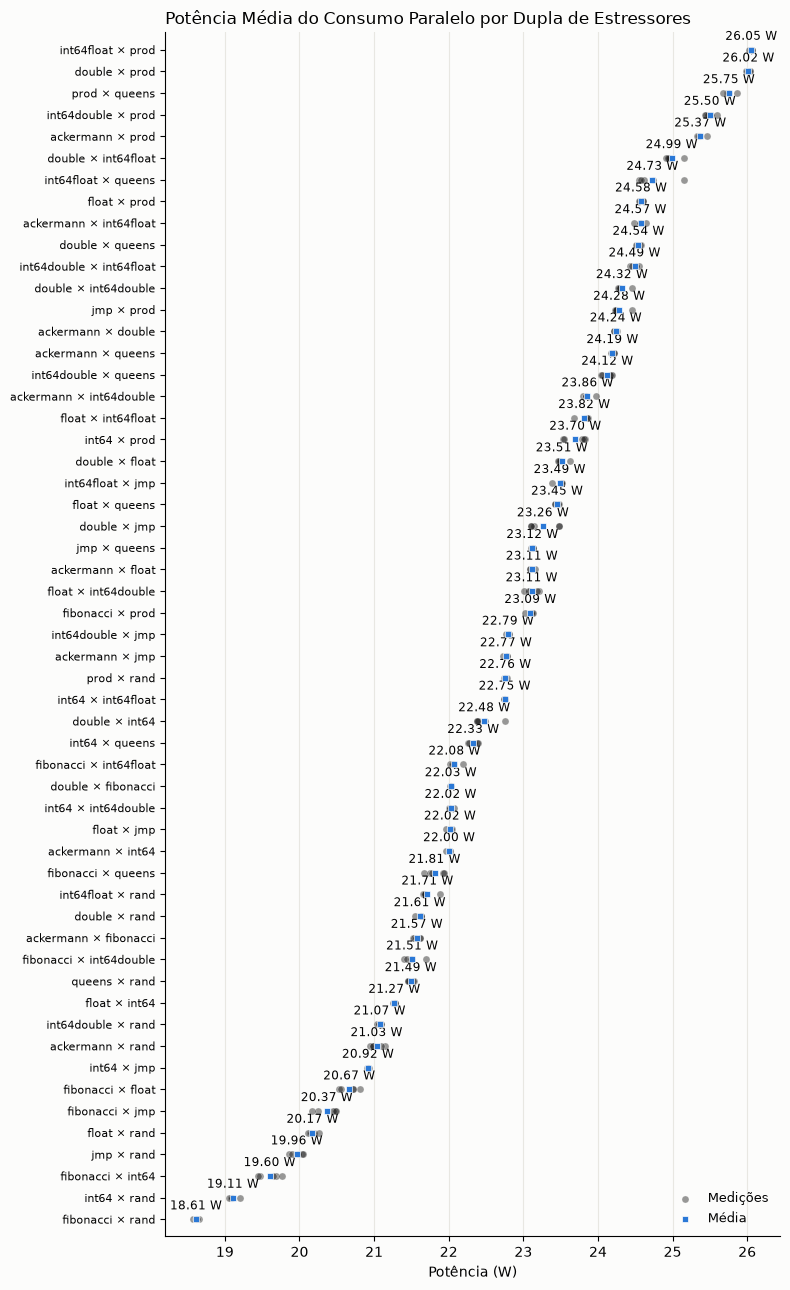

In [17]:
# grafico de pontos: potencia media do consumo PARALELO, por dupla de
# estressores. usa paralela.csv (ja processado, com a coluna "par" pronta) —
# nao reusa o pipeline de regex do sequencial porque ali o agrupamento e por
# metodo unico, e numa medicao paralela a unidade e a dupla, nao o metodo
import ast

paralelo = pd.read_csv("paralela.csv", index_col=0)
paralelo["par"] = paralelo["par"].apply(ast.literal_eval)   # string -> tupla real
paralelo["rotulo"] = paralelo["par"].apply(lambda p: f"{p[0]} × {p[1]}")

plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["savefig.facecolor"] = "#fcfcfb"
plt.rcParams["savefig.transparent"] = False

ordem = paralelo.groupby("rotulo")["Média"].mean().sort_values().index

fig, ax = plt.subplots(figsize=(8, 13))
for i, dupla in enumerate(ordem):
    valores = paralelo.loc[paralelo["rotulo"] == dupla, "Média"]
    ax.scatter(valores, [i] * len(valores), s=26, color="black", alpha=0.4,
               edgecolors="white", linewidths=0.5, zorder=2,
               label="Medições" if i == 0 else None)
    media = valores.mean()
    ax.scatter([media], [i], s=18, marker="s", color="#2a78d6", edgecolors="white",
               linewidths=0.5, zorder=3, label="Média" if i == 0 else None)
    ax.text(media, i + 0.32, f"{media:.2f} W", ha="center", va="bottom",
            fontsize=8.5, color="black")

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels(ordem, fontsize=7.8)
ax.set_ylim(-0.8, len(ordem) - 0.2)
ax.set_xlabel("Potência (W)")
ax.set_title("Potência Média do Consumo Paralelo por Dupla de Estressores", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e8e7e2", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=9)
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")
fig.tight_layout()
fig.savefig("../graficos/consumo-paralelo.png", dpi=200)
plt.show()

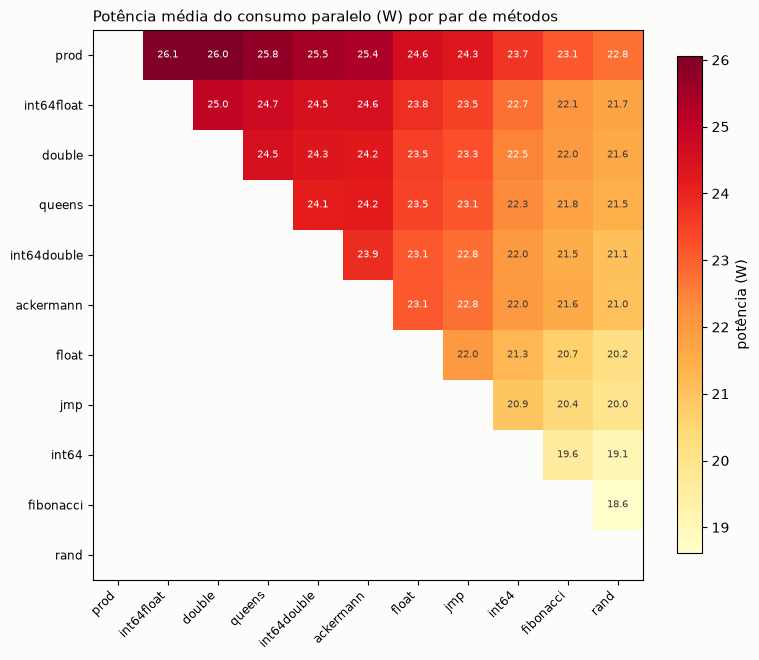

In [14]:
# heatmap 11x11: potencia media do consumo PARALELO (W), por par de metodos,
# a partir de paralela.csv. ordenado por media do metodo (mesmo criterio do
# heatmap de erro) — na pratica da a MESMA ordem do consumo isolado, o que e
# um bom sinal de que o paralelo reflete a soma dos isolados
import ast
import numpy as np

paralelo = pd.read_csv("paralela.csv", index_col=0)
paralelo["par"] = paralelo["par"].apply(ast.literal_eval)
media_par = paralelo.groupby("par")["Média"].mean()

metodos = sorted({m for par in media_par.index for m in par})
matriz = pd.DataFrame(np.nan, index=metodos, columns=metodos)
for (m1, m2), v in media_par.items():
    matriz.loc[m1, m2] = v
    matriz.loc[m2, m1] = v

# ordena pela potencia media de cada metodo com todos os parceiros (fica mais
# facil ver os metodos "caros" agrupados num canto)
ordem = matriz.mean(axis=1).sort_values(ascending=False).index
matriz = matriz.loc[ordem, ordem]

# mascara a metade inferior + diagonal (nao existe par (m,m), e a matriz e simetrica)
mask = np.triu(np.ones(matriz.shape, dtype=bool), k=1)
exibida = matriz.where(mask)

valores = matriz.values[~np.isnan(matriz.values)]
vmin, vmax = valores.min(), valores.max()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(exibida, cmap="YlOrRd", vmin=vmin, vmax=vmax)

limiar = (vmin + vmax) / 2
for i in range(len(ordem)):
    for j in range(len(ordem)):
        if mask[i, j]:
            v = matriz.iloc[i, j]
            cor = "white" if v > limiar else "#3a3a38"
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7.5, color=cor)

ax.set_xticks(range(len(ordem))); ax.set_xticklabels(ordem, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(ordem))); ax.set_yticklabels(ordem, fontsize=8.5)
ax.set_title("Potência média do consumo paralelo (W) por par de métodos",
             loc="left", fontsize=10.5)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("potência (W)")
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")
fig.tight_layout()
fig.savefig("../graficos/consumo-paralelo-heatmap.png", dpi=200)
plt.show()

In [ ]:
#agrega as 10 execucoes de cada metodo em uma linha so.
#o desvio que importa e a dispersao ENTRE execucoes: ela ja contem o ruido
#intra-janela, porque cada media e ela mesma uma media de 10 amostras.
#desvio_intra_medio NAO e barra de erro - e o teste do criterio de 2 W do artigo
agregado = filtrado.groupby("método").agg(
    media_agregada=("Média", "mean"),
    desvio_entre_execucoes=("Média", "std"),
    erro_padrao=("Média", "sem"),
    desvio_intra_medio=("Variância", "mean"),
    execucoes=("Média", "size"),
)

agregado = agregado.sort_values("media_agregada").reset_index()

print(agregado.round(4).to_string(index=False))
z

     método  media_agregada  desvio_entre_execucoes  erro_padrao  desvio_intra_medio  execucoes
       rand          9.5762                  0.0284       0.0090              0.0133         10
  fibonacci          9.7256                  0.0644       0.0204              0.0193         10
      int64          9.9271                  0.0216       0.0068              0.0124         10
        jmp         10.1452                  0.0531       0.0168              0.0228         10
      float         10.3083                  0.0115       0.0036              0.0120         10
int64double         10.5559                  0.0563       0.0178              0.0171         10
  ackermann         10.5661                  0.0593       0.0188              0.0248         10
     double         10.6993                  0.0229       0.0072              0.0101         10
     queens         10.7065                  0.0297       0.0094              0.0114         10
 int64float         10.7262             

In [9]:
# o codigo abaixo analisa o erro dos metodos dispostos nos csvs
df = pd.read_csv("erro-por-par.csv")
display(df.sort_values(by="AE", ascending=False))

,cenario,par,AE
108,max,"('prod', 'rand')",0.195879
53,min,"('prod', 'rand')",0.172858
103,max,"('int64float', 'rand')",0.170865
79,max,"('fibonacci', 'prod')",0.166786
73,max,"('double', 'rand')",0.162289
...,...,...,...
0,min,"('ackermann', 'double')",0.009714
72,max,"('double', 'queens')",0.004641
17,min,"('double', 'queens')",0.004641
4,min,"('ackermann', 'int64double')",0.004553


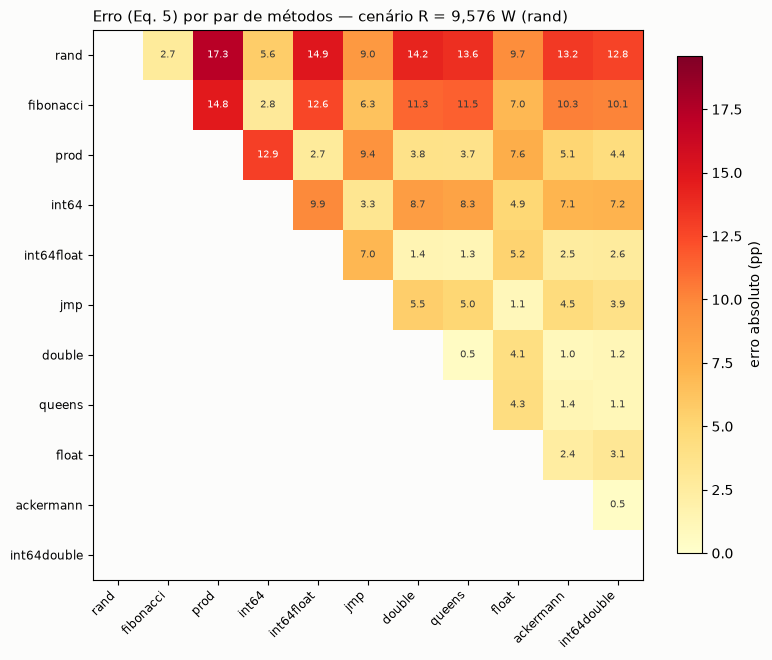

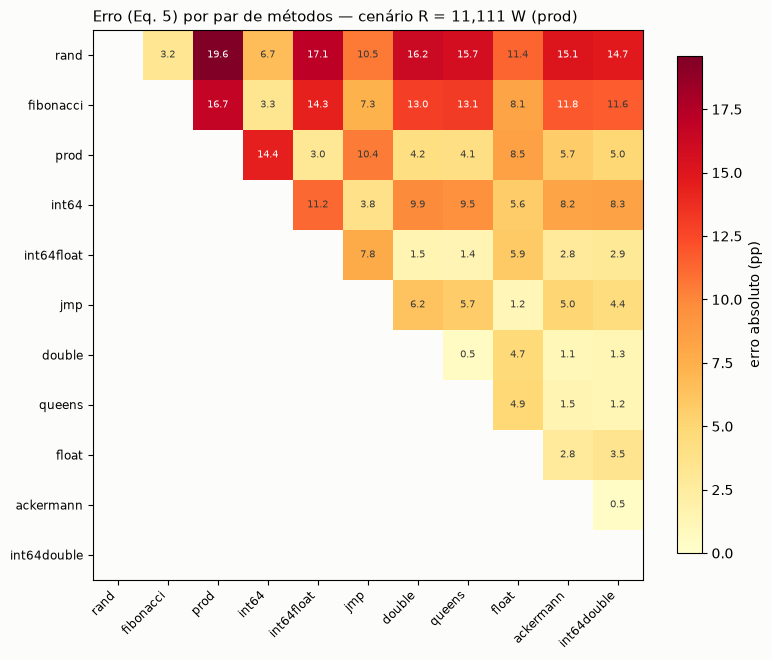

In [11]:
# heatmap 11x11: erro (Eq. 5) por par de metodos, um heatmap POR cenario de
# residual (Rmin = 9,576 W/rand, Rmax = 11,111 W/prod) — nao mistura os dois
# num unico numero; escala de cor compartilhada entre os dois para poder
# comparar visualmente
import ast
import numpy as np

erro = pd.read_csv("erro-por-par.csv")
erro["par"] = erro["par"].apply(ast.literal_eval)
piv = erro.pivot(index="par", columns="cenario", values="AE").mul(100)

ROTULO_CENARIO = {"min": "R = 9,576 W (rand)", "max": "R = 11,111 W (prod)"}
VMAX_COMUM = piv.to_numpy().max()  # mesma escala de cor nos dois heatmaps

def plotar_heatmap_erro(cenario):
    serie = piv[cenario]
    metodos = sorted({m for par in serie.index for m in par})
    matriz = pd.DataFrame(np.nan, index=metodos, columns=metodos)
    for (m1, m2), v in serie.items():
        matriz.loc[m1, m2] = v
        matriz.loc[m2, m1] = v

    # ordena pelo erro medio de cada metodo com todos os parceiros (fica mais
    # facil ver os "dificeis" agrupados num canto)
    ordem = matriz.mean(axis=1).sort_values(ascending=False).index
    matriz = matriz.loc[ordem, ordem]

    # mascara a metade inferior + diagonal (nao existe par (m,m), e a matriz e simetrica)
    mask = np.triu(np.ones(matriz.shape, dtype=bool), k=1)
    exibida = matriz.where(mask)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(exibida, cmap="YlOrRd", vmin=0, vmax=VMAX_COMUM)

    for i in range(len(ordem)):
        for j in range(len(ordem)):
            if mask[i, j]:
                v = matriz.iloc[i, j]
                cor = "white" if v > VMAX_COMUM * 0.6 else "#3a3a38"
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7.5, color=cor)

    ax.set_xticks(range(len(ordem))); ax.set_xticklabels(ordem, rotation=45, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(ordem))); ax.set_yticklabels(ordem, fontsize=8.5)
    ax.set_title(f"Erro (Eq. 5) por par de métodos — cenário {ROTULO_CENARIO[cenario]}",
                 loc="left", fontsize=10.5)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("erro absoluto (pp)")
    fig.patch.set_facecolor("#fcfcfb")
    ax.set_facecolor("#fcfcfb")
    fig.tight_layout()
    fig.savefig(f"../graficos/erro-heatmap-{cenario}.png", dpi=200)
    plt.show()

for cenario in ("min", "max"):
    plotar_heatmap_erro(cenario)